# 🏙️ Mexico City Real Estate — Apartment Price Prediction

**Goal:** Predict apartment prices in Mexico City (Distrito Federal) using location and size features.

**Pipeline:**
1. Data Wrangling
2. Exploratory Data Analysis (EDA)
3. Baseline Model
4. Ridge Regression Model
5. Evaluation & Feature Importance

## 1. Imports

In [1]:
from glob import glob

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline

## 2. Data Wrangling

The `wrangle` function applies the following steps to each CSV file:

| Step | Description |
|------|-------------|
| 1 | Filter: Distrito Federal apartments under \$100,000 |
| 2 | Remove outliers: keep 10th–90th percentile of `surface_covered_in_m2` |
| 3 | Parse `lat` and `lon` from `lat-lon` string column |
| 4 | Extract `borough` from `place_with_parent_names` |
| 5 | Drop columns with >50% null values |
| 6 | Drop low/high cardinality categorical columns |
| 7 | Drop target-leaking price columns |
| 8 | Drop multicollinear features |

> **Note:** Steps 5–8 were identified using the exploratory checks below the function.

In [2]:
def wrangle(file_path):
    df = pd.read_excel(file_path)

    # Step 1 — Filter: Distrito Federal apartments under $100,000
    mask_location = df["place_with_parent_names"].str.contains("Distrito Federal")
    mask_apt      = df["property_type"] == "apartment"
    mask_price    = df["price_aprox_usd"] < 100_000
    df = df[mask_location & mask_apt & mask_price]

    # Step 2 — Remove area outliers (keep 10th–90th percentile)
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    df = df[df["surface_covered_in_m2"].between(low, high)]

    # Step 3 — Parse coordinates from 'lat-lon' string
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Step 4 — Extract borough from pipe-delimited location string
    df["borough"] = df["place_with_parent_names"].str.split("|").str[1]
    df.drop(columns=["place_with_parent_names"], inplace=True)

    # Step 5 — Drop columns with >50% missing values
    df.drop(columns=["floor", "rooms", "expenses", "properati_url", "price_usd_per_m2"], inplace=True)

    # Step 6 — Drop low/high cardinality categoricals (no modelling value)
    df.drop(columns=["operation", "currency", "property_type"], inplace=True)

    # Step 7 — Drop target-leaking price columns
    df.drop(columns=["price", "price_aprox_local_currency", "price_per_m2"], inplace=True)

    # Step 8 — Drop multicollinear feature (correlated with surface_covered_in_m2)
    df.drop(columns=["surface_total_in_m2"], inplace=True)

    return df

### 2.1 Load & Combine All Files

In [3]:
files = glob("../data/mexico-city-real-estate-*.xlsx")
frames = [wrangle(file) for file in files]
df = pd.concat(frames, ignore_index=True)

print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5473 entries, 0 to 5472
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        5473 non-null   float64
 1   surface_covered_in_m2  5473 non-null   float64
 2   lat                    5149 non-null   float64
 3   lon                    5149 non-null   float64
 4   borough                5473 non-null   object 
dtypes: float64(4), object(1)
memory usage: 213.9+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,borough
0,94022.66,57.0,23.634501,-102.552788,Benito Juárez
1,70880.12,56.0,19.402413,-99.095391,Iztacalco
2,68228.99,80.0,19.357820,-99.149406,Benito Juárez
3,24235.78,60.0,19.504985,-99.208557,Azcapotzalco
4,94140.20,50.0,19.354219,-99.126244,Coyoacán


### 2.2 Exploratory Checks (used to inform wrangle decisions)

In [4]:
# Check null ratios — used to decide Step 5
df.isnull().sum() / len(df)

price_aprox_usd          0.0000
surface_covered_in_m2    0.0000
lat                      0.0592
lon                      0.0592
borough                  0.0000
dtype: float64

In [5]:
# Check cardinality of object columns — used to decide Step 6
df.select_dtypes("object").nunique()

borough    15
dtype: int64

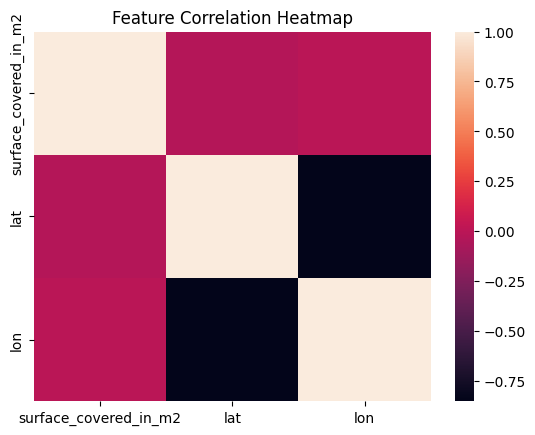

In [6]:
# Check multicollinearity between numeric features — used to decide Step 8
corr = df.select_dtypes("number").drop(columns="price_aprox_usd").corr()
sns.heatmap(corr)
plt.title("Feature Correlation Heatmap")
plt.show()

## 3. Exploratory Data Analysis (EDA)

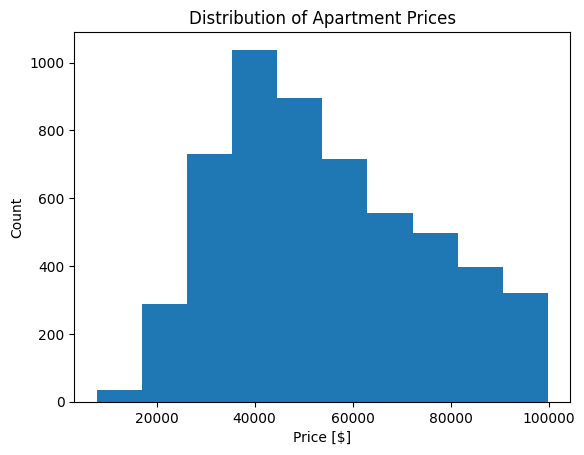

In [7]:
# Distribution of apartment prices
fig, ax = plt.subplots()
ax.hist(df["price_aprox_usd"])
ax.set_xlabel("Price [$]")
ax.set_ylabel("Count")
ax.set_title("Distribution of Apartment Prices")
plt.show()

## Observations

- The distribution is **right-skewed** (skewed to the right).
- Most apartments are priced between **$30,000 and $60,000**.
- The peak (mode) is around **$40,000**.
- Very few apartments exceed **$80,000**.

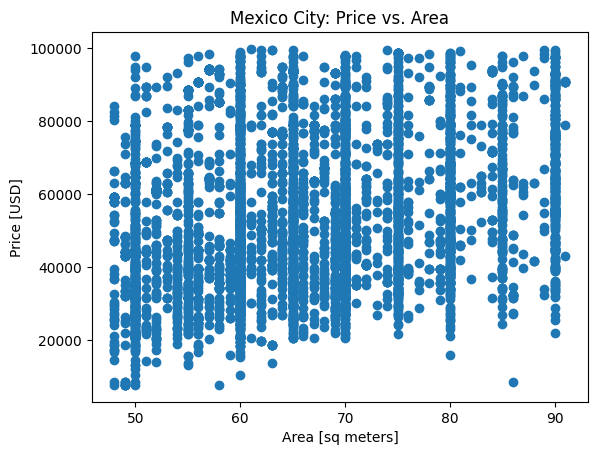

In [8]:
# Price vs. Area scatter plot
fig, ax = plt.subplots()
ax.scatter(x=df["surface_covered_in_m2"], y=df["price_aprox_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Mexico City: Price vs. Area")
plt.show()

## Observations

- There is a **weak positive correlation** between area and price.
- Most apartments range between **45–90 sq meters**.
- The data shows **high variance** — same area can have very different prices,
  suggesting other factors (like location/borough) also affect price strongly.
- No clear single trend line, which means **area alone is not enough** to predict price.

## 4. Split Data

In [9]:
X_train = df[["surface_covered_in_m2", "lat", "lon", "borough"]]
y_train = df["price_aprox_usd"]

## 5. Baseline Model

In [10]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt price:", round(y_mean, 2))
print("Baseline MAE: ", round(baseline_mae, 2))

Mean apt price: 54246.53
Baseline MAE:  17239.94


## 6. Ridge Regression Model

In [11]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    Ridge()
)

model.fit(X_train, y_train)
print("Model trained successfully ✅")

Model trained successfully ✅


## 7. Predictions on Test Set

In [12]:
X_test = pd.read_excel("../data/mexico-city-test-features.xlsx")
print(X_test.info())
X_test.head()

<class 'pandas.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surface_covered_in_m2  1041 non-null   int64  
 1   lat                    986 non-null    float64
 2   lon                    986 non-null    float64
 3   borough                1041 non-null   str    
dtypes: float64(2), int64(1), str(1)
memory usage: 32.7 KB
None


,surface_covered_in_m2,lat,lon,borough
0,60,19.493185,-99.205755,Azcapotzalco
1,55,19.307247,-99.166700,Coyoacán
2,50,19.363469,-99.010141,Iztapalapa
3,60,19.474655,-99.189277,Azcapotzalco
4,74,19.394628,-99.143842,Benito Juárez


In [13]:
y_test_pred = pd.Series(model.predict(X_test))
y_test_pred.head()

0    53538.366480
1    53171.988369
2    34263.884179
3    53488.425607
4    68738.924884
dtype: float64

In [14]:
y_pred_train = model.predict(X_train)

print("Training MAE:", round(mean_absolute_error(y_train, y_pred_train), 2))

Training MAE: 14943.17


## 8. Feature Importance

In [15]:
coefficients  = model.named_steps["ridge"].coef_
feature_names = model.named_steps["onehotencoder"].get_feature_names()

feat_imp = pd.Series(coefficients, index=feature_names)
feat_imp = feat_imp.sort_values(key=abs)
feat_imp

C:\Users\usfmg\AppData\Local\Temp\ipykernel_8352\1338007221.py:2: FutureWarning: `get_feature_names` is deprecated in all of sklearn. Use `get_feature_names_out` instead.
  feature_names = model.named_steps["onehotencoder"].get_feature_names()


surface_covered_in_m2               291.654156
borough_Cuauhtémoc                 -350.531990
borough_Iztacalco                   405.403127
lat                                 478.901375
borough_Xochimilco                  929.857400
borough_Miguel Hidalgo             1977.314718
borough_Azcapotzalco               2459.288646
lon                               -2492.221814
borough_Álvaro Obregón             3275.121061
borough_Coyoacán                   3737.561001
borough_Venustiano Carranza       -5609.918629
borough_La Magdalena Contreras    -5925.666450
borough_Gustavo A. Madero         -6637.429757
borough_Cuajimalpa de Morelos      9157.269123
borough_Tlalpan                   10319.429804
borough_Iztapalapa               -13349.017448
borough_Benito Juárez             13778.188880
borough_Tláhuac                  -14166.869486
dtype: float64

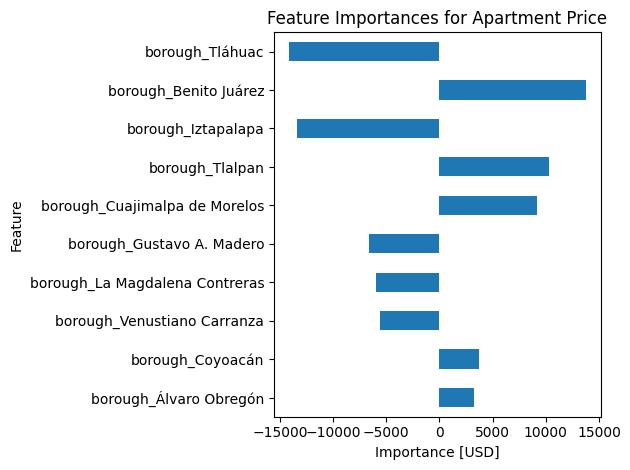

In [16]:
fig, ax = plt.subplots()
feat_imp.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax)
ax.set_xlabel("Importance [USD]")
ax.set_ylabel("Feature")
ax.set_title("Feature Importances for Apartment Price")
plt.tight_layout()
plt.show()

## Observations

- All top 10 most influential features are **borough (neighborhood) features**,
  which means **location is the strongest predictor** of apartment price.
- **borough_Benito Juárez** has the highest positive importance (~+13,000),
  meaning apartments there are ~$13,000 **more expensive** than average.
- **borough_Tláhuac** and **borough_Iztapalapa** have the strongest negative values,
  meaning apartments there are significantly **cheaper** than average.
- The model confirms that **where** an apartment is matters more than **how big** it is.

In [17]:
print("Baseline MAE: ", 17_239.94)
print("Training MAE: ", round(14_943.17, 2))
print("Improvement:  ", round(17_239.94 - 14_943.17, 2), "USD")
print("Improvement %:", round((1 - 14_943.17 / 17_239.94) * 100, 1), "%")

Baseline MAE:  17239.94
Training MAE:  14943.17
Improvement:   2296.77 USD
Improvement %: 13.3 %


## Conclusion

- The Ridge Regression model outperforms the baseline by **~$2,300 (13%)**.
- **Location (borough)** is the most influential feature — more than size.
- Benito Juárez adds ~$13k to price; Tláhuac reduces it by ~$14k.
- Further improvements could come from adding more location features 
  or trying a non-linear model like Random Forest.